# 3-Step Grid Search: Model Class Comparison

Compare three model classes from the (σ₀, σ₁, σ₂) grid search against the human d' curve:
1. **3-step**: σ₀ > 0 and σ₁ > σ₂ (encoding noise + two-regime drift)
2. **2-step**: σ₀ = 0 and σ₁ > σ₂ (no encoding noise, two-regime drift)
3. **Constant noise**: σ₀ = 0 and σ₁ = σ₂ (single diffusion rate)

Only models satisfying σ₀ ≥ σ₁ ≥ σ₂ are considered.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Results directory ──
RESULTS_DIR = (
    '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/3step_grid_search_metric-cosine_t4_nmc1_task0'
)

#/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/3step_grid_search_metric-cosine_t5_nmc1_task0/
# ── Load merged grid search results ──
grid = np.load(os.path.join(RESULTS_DIR, 'grid_search_results_3step_t5.npz'))
sigma0_grid = grid['sigma0_grid']
sigma1_grid = grid['sigma1_grid']
sigma2_grid = grid['sigma2_grid']
ISI_VALUES = tuple(grid['isi_values'].astype(int))

# 3D d' arrays: results[isi][i_s0, i_s1, i_s2]
results = {isi: grid[f'dprime_isi{isi}'] for isi in ISI_VALUES}

# ── Flatten into DataFrame ──
rows = []
for i0, s0 in enumerate(sigma0_grid):
    for i1, s1 in enumerate(sigma1_grid):
        for i2, s2 in enumerate(sigma2_grid):
            row = {'sigma0': s0, 'sigma1': s1, 'sigma2': s2,
                   'i_s0': i0, 'i_s1': i1, 'i_s2': i2}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = results[isi][i0, i1, i2]
            rows.append(row)

df = pd.DataFrame(rows)
print(f'Total grid points: {len(df)}')
print(f'Grid: {len(sigma0_grid)} x {len(sigma1_grid)} x {len(sigma2_grid)}')
print(f'ISI values: {ISI_VALUES}')
print(f'sigma0: {sigma0_grid}')
print(f'sigma1: {sigma1_grid}')
print(f'sigma2: {sigma2_grid}')

Total grid points: 3375
Grid: 15 x 15 x 15
ISI values: (0, 1, 2, 4, 8, 16, 32, 64)
sigma0: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]
sigma1: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]
sigma2: [0.00000000e+00 1.00000000e-02 1.82549228e-02 3.33242206e-02
 6.08331075e-02 1.11050368e-01 2.02721590e-01 3.70066697e-01
 6.75553899e-01 1.23321843e+00 2.25123072e+00 4.10960430e+00
 7.50205092e+00 1.36949360e+01 2.50000000e+01]


In [2]:
# ── Load human d' curve ──
from utls.runners_utils import load_experiment_data, compute_human_curve
from utls.analysis_helpers import roc_for_isi, auroc_to_dprime

which_task = 0   # first multi-ISI task
is_multi = True

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi=None, is_multi=is_multi)
)

# Human curve ISIs for is_multi: [0, 1, 2, 4, 8, 16, 32, 64]
human_isis_full = np.array([0, 1, 2, 4, 8, 16, 32, 64])
human_curve_full = compute_human_curve(human_runs, is_multi, which_isi=None)

# Grid ISIs (from npz) may not include ISI=3 — align to grid
grid_isis = np.array(ISI_VALUES)
mask = np.isin(human_isis_full, grid_isis)
human_dp = human_curve_full[mask]
isis = human_isis_full[mask]

assert len(human_dp) == len(grid_isis), (
    f'Mismatch: human has {len(human_dp)} ISIs, grid has {len(grid_isis)}'
)

# ── Compute per-participant d' → SEM ──
per_subj = []
for run in human_runs:
    row = []
    for isi_val in grid_isis:
        res = roc_for_isi(run, isi_val)
        row.append(auroc_to_dprime(res[2]) if res is not None else np.nan)
    per_subj.append(row)
human_dp_mat = np.array(per_subj)  # (N_participants, N_isi)
n_valid = np.sum(~np.isnan(human_dp_mat), axis=0)
human_sem = np.nanstd(human_dp_mat, axis=0, ddof=1) / np.sqrt(n_valid)

print(f'Task: {hr_task_name} ({task_name})')
print(f'Human participants: {len(human_runs)}')
print(f'Aligned ISIs: {isis}')
print(f'Human d\': {np.round(human_dp, 3)}')
print(f'Human SEM: {np.round(human_sem, 3)}')

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


Task: Industrial and Nature (env-sounds)
Human participants: 104
Aligned ISIs: [ 0  1  2  4  8 16 32 64]
Human d': [3.422 2.995 2.433 2.154 2.014 1.894 1.736 1.581]
Human SEM: [0.141 0.13  0.106 0.103 0.094 0.083 0.069 0.083]


In [3]:
# ── Filter: sigma0 >= sigma1 >= sigma2 ──
decreasing = (df['sigma0'] >= df['sigma1']) & (df['sigma1'] >= df['sigma2'])
df_filt = df.copy()
print(f'Decreasing constraint: {len(df_filt)}/{len(df)} triples kept')

# ── Classify model types ──
def classify(row):
    s0, s1, s2 = row['sigma0'], row['sigma1'], row['sigma2']
    if s0 == s1 and s1 == s2:
        return 'constant'
    elif (s0 == s1 and s1 > s2) or (s0 == 0 and s1 > s2):
        return '2-step'
    elif s0 > 0 and s0 > s1 and s1 > s2:
        return '3-step'
    else:
        return 'other'

df_filt['model_class'] = df_filt.apply(classify, axis=1)
print('\nModel class counts:')
print(df_filt['model_class'].value_counts().to_string())

Decreasing constraint: 3375/3375 triples kept

Model class counts:
model_class
other       2695
3-step       455
2-step       210
constant      15


In [4]:
# ── Compute MSE to human curve ──
dp_cols = [f'dprime_isi{isi}' for isi in grid_isis]
model_dp_matrix = df_filt[dp_cols].values  # (n_models, n_isis)

# MSE per model (ignoring NaN entries)
diff = model_dp_matrix - human_dp[np.newaxis, :]
mse = np.nanmean(diff**2, axis=1)
df_filt['mse'] = mse

# Drop rows that are all NaN
df_filt = df_filt.dropna(subset=['mse'])
print(f'Models with valid MSE: {len(df_filt)}')
print(f'MSE range: {df_filt["mse"].min():.4f} – {df_filt["mse"].max():.4f}')

Models with valid MSE: 3366
MSE range: 0.0596 – 20.1036


/tmp/ipykernel_3517620/4011528738.py:7: RuntimeWarning: Mean of empty slice
  mse = np.nanmean(diff**2, axis=1)


In [5]:
# ── Best models per class ──
N_BEST = 15
CLASS_ORDER = ['3-step', '2-step', 'constant']

best_per_class = {}
for cls in CLASS_ORDER:
    sub = df_filt[df_filt['model_class'] == cls].nsmallest(N_BEST, 'mse')
    best_per_class[cls] = sub
    if len(sub) == 0:
        print(f'\n=== {cls}: no models ===')
        continue
    print(f'\n=== {cls} (n={len(df_filt[df_filt["model_class"]==cls])}) — top {len(sub)} by MSE ===')
    display_cols = ['sigma0', 'sigma1', 'sigma2', 'mse']
    print(sub[display_cols].to_string(index=False, float_format='{:.4f}'.format))


=== 3-step (n=455) — top 15 by MSE ===
 sigma0  sigma1  sigma2    mse
13.6949  2.2512  0.6756 0.0596
13.6949  1.2332  0.6756 0.0981
13.6949  2.2512  0.3701 0.1527
13.6949  1.2332  0.3701 0.2153
 7.5021  2.2512  0.3701 0.2354
13.6949  2.2512  0.2027 0.2409
13.6949  0.6756  0.3701 0.2511
13.6949  2.2512  0.1111 0.2761
13.6949  2.2512  0.0608 0.2871
13.6949  2.2512  0.0333 0.2908
13.6949  2.2512  0.0183 0.2914
13.6949  2.2512  0.0000 0.2915
13.6949  2.2512  0.0100 0.2918
 7.5021  2.2512  0.2027 0.3032
13.6949  1.2332  0.2027 0.3217

=== 2-step (n=210) — top 15 by MSE ===
 sigma0  sigma1  sigma2    mse
 0.6756  0.6756  0.0000 1.6190
 0.6756  0.6756  0.0100 1.6206
 0.6756  0.6756  0.0183 1.6227
 0.6756  0.6756  0.0333 1.6360
 0.6756  0.6756  0.0608 1.7101
 0.6756  0.6756  0.1111 2.0306
 0.0000  0.6756  0.0000 2.2032
 0.0000  0.6756  0.0100 2.2082
 0.0000  0.6756  0.0183 2.2201
 0.0000  0.6756  0.0333 2.2593
 0.0000  0.6756  0.0608 2.3921
 0.6756  0.6756  0.2027 2.6106
 0.0000  0.6756  0.11

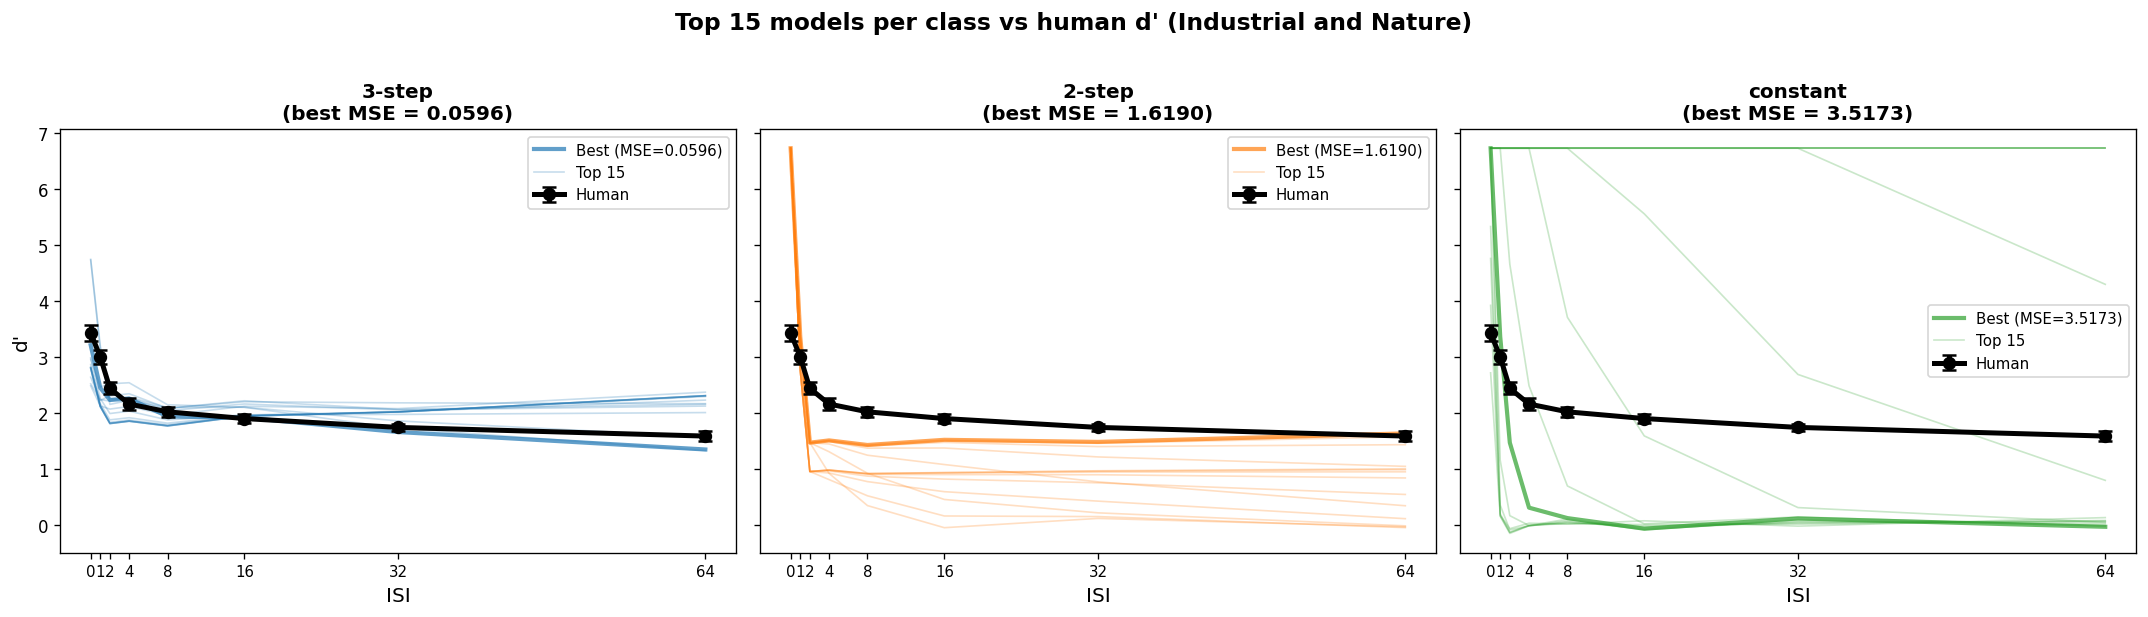

In [6]:
# ── Plot: best models per class vs human curve ──
CLASS_COLORS = {'3-step': 'tab:blue', '2-step': 'tab:orange', 'constant': 'tab:green'}

# Use ISI values themselves for x-coordinates for correct spacing
x = np.array(grid_isis)

# Check if model error bars have been computed (from a later cell)
_have_model_eb = 'model_errorbars' in dir() and model_errorbars

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, cls in zip(axes, CLASS_ORDER):
    sub = best_per_class[cls]
    color = CLASS_COLORS[cls]

    # Plot each model curve
    for i, (_, row) in enumerate(sub.iterrows()):
        model_curve = row[dp_cols].values.astype(float)
        alpha = 0.7 if i == 0 else 0.25
        lw = 2.5 if i == 0 else 1.0
        label = f'Best (MSE={row["mse"]:.4f})' if i == 0 else (f'Top {N_BEST}' if i == 1 else None)

        if i == 0 and _have_model_eb and cls in model_errorbars:
            # Best model with error bars
            eb = model_errorbars[cls]
            ax.errorbar(x, model_curve, yerr=eb['sem'], fmt='-o', color=color,
                        alpha=0.8, linewidth=lw, markersize=5, capsize=3,
                        capthick=1.2, label=label)
        else:
            ax.plot(x, model_curve, '-', color=color, alpha=alpha, linewidth=lw, label=label)

    # Human curve with error bars
    ax.errorbar(x, human_dp, yerr=human_sem, fmt='o-k', linewidth=3, markersize=7,
                capsize=4, capthick=1.5, label='Human', zorder=10)

    ax.set_xticks(x)
    ax.set_xticklabels(grid_isis, fontsize=9)
    ax.set_xlabel('ISI', fontsize=12)
    if ax == axes[0]:
        ax.set_ylabel("d'", fontsize=12)
    ax.set_title(f'{cls}\n(best MSE = {sub["mse"].min():.4f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle(f"Top {N_BEST} models per class vs human d' ({hr_task_name})",
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

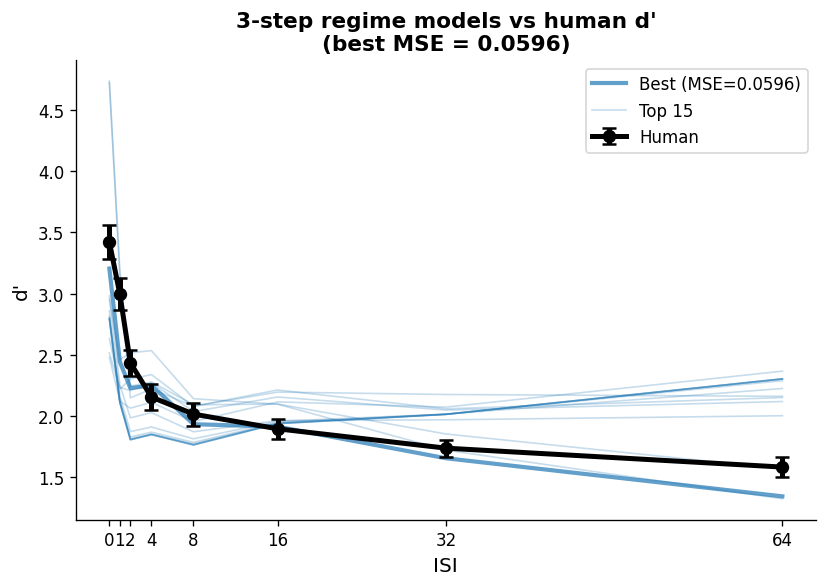

In [7]:
# ── Plot: 3-step regime models vs human curve ──

fig, ax = plt.subplots(figsize=(7, 5))
x = np.array(grid_isis)
cls = '3-step'
sub = best_per_class[cls]
color = CLASS_COLORS[cls]

_have_model_eb = 'model_errorbars' in dir() and model_errorbars

# Plot each model curve
for i, (_, row) in enumerate(sub.iterrows()):
    model_curve = row[dp_cols].values.astype(float)
    alpha = 0.7 if i == 0 else 0.25
    lw = 2.5 if i == 0 else 1.0
    label = f'Best (MSE={row["mse"]:.4f})' if i == 0 else (f'Top {N_BEST}' if i == 1 else None)

    if i == 0 and _have_model_eb and cls in model_errorbars:
        eb = model_errorbars[cls]
        ax.errorbar(x, model_curve, yerr=eb['sem'], fmt='-o', color=color,
                    alpha=0.8, linewidth=lw, markersize=5, capsize=3,
                    capthick=1.2, label=label)
    else:
        ax.plot(x, model_curve, '-', color=color, alpha=alpha, linewidth=lw, label=label)

# Human curve with error bars
ax.errorbar(x, human_dp, yerr=human_sem, fmt='o-k', linewidth=3, markersize=7,
            capsize=4, capthick=1.5, label='Human', zorder=10)

ax.set_xticks(x)
ax.set_xticklabels(grid_isis, fontsize=10)
ax.set_xlabel('ISI', fontsize=12)
ax.set_ylabel("d'", fontsize=12)
ax.set_title(f"3-step regime models vs human d'\n(best MSE = {sub['mse'].min():.4f})", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()

Model class  N models  Best MSE  Mean top-15 MSE   Best σ₀  Best σ₁  Best σ₂
     3-step       455  0.059647         0.240446 13.694936 2.251231 0.675554
     2-step       210  1.619008         2.214536  0.675554 0.675554 0.000000
   constant        15  3.517311        10.327319  0.675554 0.675554 0.675554


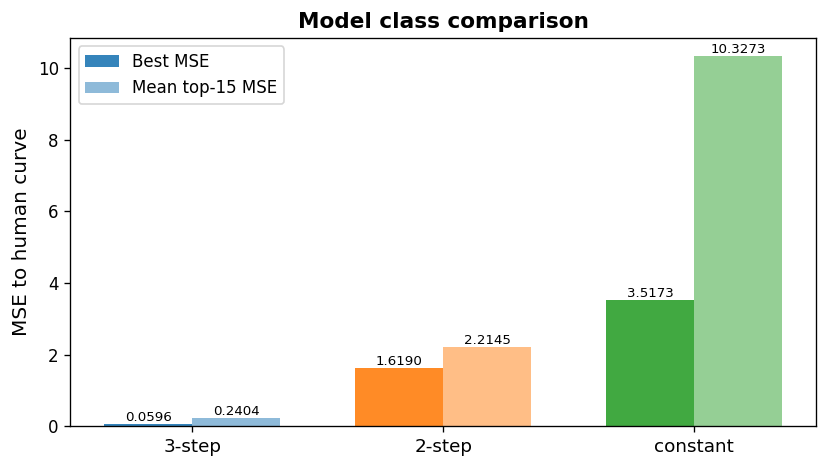

In [8]:
# ── Summary: MSE comparison across classes ──
summary_rows = []
for cls in CLASS_ORDER:
    sub = best_per_class[cls]
    n_total = len(df_filt[df_filt['model_class'] == cls])
    if len(sub) == 0:
        continue
    best_row = sub.iloc[0]
    summary_rows.append({
        'Model class': cls,
        'N models': n_total,
        'Best MSE': sub['mse'].min(),
        f'Mean top-{N_BEST} MSE': sub['mse'].mean(),
        'Best σ₀': best_row['sigma0'],
        'Best σ₁': best_row['sigma1'],
        'Best σ₂': best_row['sigma2'],
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

# ── Bar plot ──
fig, ax = plt.subplots(figsize=(7, 4))
classes = summary['Model class']
x = np.arange(len(classes))
width = 0.35

bars1 = ax.bar(x - width/2, summary['Best MSE'], width,
               label='Best MSE', color=[CLASS_COLORS[c] for c in classes], alpha=0.9)
bars2 = ax.bar(x + width/2, summary[f'Mean top-{N_BEST} MSE'], width,
               label=f'Mean top-{N_BEST} MSE', color=[CLASS_COLORS[c] for c in classes], alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylabel('MSE to human curve', fontsize=12)
ax.set_title('Model class comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Add value labels
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.4f}',
            ha='center', va='bottom', fontsize=8)

fig.tight_layout()
plt.show()

In [9]:
# # ── Store best parameters for downstream use ──
# print('\nBest parameters per class:')
# for cls in CLASS_ORDER:
#     sub = best_per_class[cls]
#     if len(sub) == 0:
#         continue
#     best = sub.iloc[0]
#     print(f'  {cls}: σ₀={best["sigma0"]:.4f}, σ₁={best["sigma1"]:.4f}, '
#           f'σ₂={best["sigma2"]:.4f}  (MSE={# ── Store best parameters for downstream use ──
# print('\nBest parameters per class:')
# for cls in CLASS_ORDER:
#     sub = best_per_class[cls]
#     if len(sub) == 0:
#         continue
#     best = sub.iloc[0]
#     print(f'  {cls}: σ₀={best["sigma0"]:.4f}, σ₁={best["sigma1"]:.4f}, '
#           f'σ₂={best["sigma2"]:.4f}  (MSE={best["mse"]:.4f})'):.4f})')

In [10]:

exp_list_single, all_files_single, name_to_idx_single, human_runs_single, task_name_single, hr_task_name_single = (
    load_experiment_data(which_task, which_isi=16, is_multi=False)
)

print(name_to_idx_single)

{'/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/mem_stim_0.wav': 0, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/mem_stim_1.wav': 1, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/mem_stim_10.wav': 2, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/mem_stim_11.wav': 3, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/mem_stim_12.wav': 4, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/mem_stim_13.wav': 5, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/mem_stim_14.wav': 6, '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_s

In [11]:
# Human curve ISIs for is_multi: [0, 1, 2, 4, 8, 16, 32, 64]
human_isis_full_single = np.array([0, 16])
human_curve_full_single = compute_human_curve(human_runs_single, False, which_isi=16)
print(human_curve_full_single)

[3.16032807 1.69366692]


In [12]:
# ── Find the best class (lowest mean MSE), and top 15 best parameters from its models ──

# Determine best class by mean MSE
class_mse_means = {}
for cls in CLASS_ORDER:
    sub = best_per_class[cls]
    if len(sub) == 0: continue
    class_mse_means[cls] = sub['mse'].mean()
if len(class_mse_means) == 0:
    print("No best parameters found across classes.")
else:
    best_class = min(class_mse_means, key=class_mse_means.get)
    print(f"\nBest class by mean MSE: {best_class}")

    # Select top 15 models of best class by lowest MSE
    best_class_df = best_per_class[best_class].sort_values('mse')
    top15 = best_class_df.head(15)
    param_names = ["sigma0", "sigma1", "sigma2"]
    top15_params = [[row["sigma0"], row["sigma1"], row["sigma2"]] for _, row in top15.iterrows()]

    print("\nTop 15 parameter sets from best class:")
    for i, row in top15.iterrows():
        print(f'  {best_class}: σ₀={row["sigma0"]:.4f}, σ₁={row["sigma1"]:.4f}, '
              f'σ₂={row["sigma2"]:.4f}  (MSE={row["mse"]:.4f})')

    print("\nList of parameter lists (for refined grid search):")
    print(top15_params)


Best class by mean MSE: 3-step

Top 15 parameter sets from best class:
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.6756  (MSE=0.0596)
  3-step: σ₀=13.6949, σ₁=1.2332, σ₂=0.6756  (MSE=0.0981)
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.3701  (MSE=0.1527)
  3-step: σ₀=13.6949, σ₁=1.2332, σ₂=0.3701  (MSE=0.2153)
  3-step: σ₀=7.5021, σ₁=2.2512, σ₂=0.3701  (MSE=0.2354)
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.2027  (MSE=0.2409)
  3-step: σ₀=13.6949, σ₁=0.6756, σ₂=0.3701  (MSE=0.2511)
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.1111  (MSE=0.2761)
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.0608  (MSE=0.2871)
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.0333  (MSE=0.2908)
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.0183  (MSE=0.2914)
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.0000  (MSE=0.2915)
  3-step: σ₀=13.6949, σ₁=2.2512, σ₂=0.0100  (MSE=0.2918)
  3-step: σ₀=7.5021, σ₁=2.2512, σ₂=0.2027  (MSE=0.3032)
  3-step: σ₀=13.6949, σ₁=1.2332, σ₂=0.2027  (MSE=0.3217)

List of parameter lists (for refined grid search):
[[13.694936030946371, 2

In [13]:
print(len(top15_params))

15


In [14]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import types
import sys

# Mock 'cox' and 'cox.store' so constants.py doesn't crash
cox_mock = types.ModuleType('cox')
store_mock = types.ModuleType('cox.store')
store_mock.PYTORCH_STATE = 'pytorch_state'  # the only attr actually used
cox_mock.store = store_mock
sys.modules['cox'] = cox_mock
sys.modules['cox.store'] = store_mock


# project paths
sys.path.insert(0, os.path.abspath('..'))
sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

import torch

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set

from utls.encoders import *
from utls.runners_v2 import run_model_core, make_noise_schedule
from utls.runners_utils import load_experiment_data, build_encoder, encode_stimuli
from utls.toy_experiments import make_high_diversity_sequences
from utls.roc_utils import roc_from_arrays
from utls.analysis_helpers import auroc_to_dprime

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
print('Imports OK')

Imports OK


In [15]:
encoder_cfg = dict(
    encoder_type='resnet50',
    model_name='resnet50',
    task='word_speaker_audioset',
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=False,
    device='cuda',
    layer='layer4',
)

print('Building encoder: resnet50 / layer4 ...')
encoder = build_encoder(encoder_cfg)

print(f'Encoding {len(all_files)} stimuli ...')
X0 = encode_stimuli(encoder, all_files)
print(f'X0 shape: {X0.shape}')
print(f'Any NaN: {torch.isnan(X0).any().item()}')

Building encoder: resnet50 / layer4 ...
LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
### WARNING: UNABLE TO FIND JSIN AUDIO TRAINING DATASET FILES. IF TRAINING AUDIO MODELS, CHANGE PATH SPECIFIED IN analysis_scripts/default_paths.py. MODELS CAN BE LOADED AND TESTED WITHOUT THESE FILES. ###
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoding 80 stimuli ...
X0 shape: torch.Size([80, 186368])
Any NaN: False


In [16]:
ISI_VALUES = [0, 1, 2, 4, 8, 16, 32, 64]
N_SEQUENCES = 200
SEQ_LENGTH = 120

stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f'Stimulus pool: {len(stimulus_pool)} unique stimuli')

experiment_list, isi_keys = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=ISI_VALUES,
    n_sequences=N_SEQUENCES,
    length=SEQ_LENGTH,
    min_pairs_per_isi=4,
    seed=420483,
)

print(f'{len(experiment_list)} sequences, {len(experiment_list[0])} trials each')

Aggregate ISI usage across all sequences:
  ISI -1: 8000
  ISI 0: 2124
  ISI 1: 1866
  ISI 2: 2010
  ISI 4: 2092
  ISI 8: 2020
  ISI 16: 1936
  ISI 32: 1968
  ISI 64: 1984
200 sequences, 120 trials each


In [17]:
exp_list_single_no_seq = [
    [s.replace('/sequences/', '/') for s in seq]
    for seq in exp_list_single
]
exp_list_single_no_seq[0][0], experiment_list[0][0]

('/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_24.wav',
 '/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_41.wav')

In [ ]:
# import sys, os, time
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# sys.path.insert(0, os.path.abspath('../src/model'))
# from run_3step_grid_search import run_mc_dprime

# best_sigma0, best_sigma1, best_sigma2 = 13.694936, 2.251231, 0.375554
# t_step = 4
# metric = "cosine"

# N_EXP_LIST = [1, 10, 30, 100]
# seed_base = 3010

# dprime_curves_per_expnum = []
# std_curves_per_expnum = []

# t_start = time.perf_counter()

# for i, nexps in enumerate(N_EXP_LIST):
#     experiment_sublist = experiment_list[:nexps]
#     print(f"\nRunning model on {nexps} experiments...")

#     # one d' curve per experiment
#     per_exp_curves = []

#     for j, exp in enumerate(experiment_sublist):
#         dp, _ = run_mc_dprime(
#             best_sigma0,
#             best_sigma1,
#             best_sigma2,
#             X0=X0,
#             name_to_idx=name_to_idx,
#             experiment_list=[exp],   # exactly one experiment
#             t_step=t_step,
#             isi_values=tuple(ISI_VALUES),
#             n_mc=1,                  # exactly one MC simulation
#             seed=seed_base + i * 10000 + j,
#             metric=metric,
#         )
        
#         exp_curve = []
#         for isi in sorted(dp.keys()):
#             #print(isi, dp[isi])
#             exp_curve.append(dp[isi])
#         per_exp_curves.append(np.asarray(exp_curve, dtype=float))

#     per_exp_curves = np.vstack(per_exp_curves)   # shape: [nexps, n_isi]

#     dprime_curves_per_expnum.append(np.nanmean(per_exp_curves, axis=0))
#     std_curves_per_expnum.append(np.nanstd(per_exp_curves, axis=0))

# elapsed = time.perf_counter() - t_start
# print(f"\nCompleted all experiment number conditions in {elapsed:.1f}s")

# dprime_curves_per_expnum = np.vstack(dprime_curves_per_expnum)
# std_curves_per_expnum = np.vstack(std_curves_per_expnum)

# plt.figure(figsize=(10, 6))
# for i, nexps in enumerate(N_EXP_LIST):
#     plt.plot(ISI_VALUES, dprime_curves_per_expnum[i], "-o", label=f"{nexps} experiments")
#     plt.fill_between(
#         ISI_VALUES,
#         dprime_curves_per_expnum[i] - std_curves_per_expnum[i],
#         dprime_curves_per_expnum[i] + std_curves_per_expnum[i],
#         alpha=0.15,
#     )

# plt.xlabel("ISI")
# plt.ylabel("d-prime")
# plt.title("Average model d-prime vs ISI as number of experiments increases")
# plt.legend()
# plt.tight_layout()
# plt.show()

# df_curves_varying_exp = pd.DataFrame(
#     dprime_curves_per_expnum,
#     columns=[f"dprime_mean_isi{isi}" for isi in ISI_VALUES],
# )
# for idx, isi in enumerate(ISI_VALUES):
#     df_curves_varying_exp[f"dprime_std_isi{isi}"] = std_curves_per_expnum[:, idx]
# df_curves_varying_exp["n_experiments_used"] = N_EXP_LIST

# df_curves_varying_exp



Running model on 1 experiments...

Running model on 10 experiments...

Running model on 30 experiments...

Running model on 100 experiments...


In [ ]:
# # Stability analysis for a single hyperparameter set (fixed sigma0, sigma1, sigma2) across many seeds

# sys.path.insert(0, os.path.abspath('../src/model'))
# from run_3step_grid_search import run_mc_dprime

# # Choose ONE set of best-fit hyperparameters (these can be replaced with your favorite ones)
# best_sigma0, best_sigma1, best_sigma2 = 13.106418, 2.671129, 0.487541


# t_step = 4
# metric = 'cosine'
# N_repeats = 100  # Number of repeats (seeds) — increase as needed for desired stability analysis
# n_mc_grid = 1    # Leave as 1 (one MC per experiment run) — or adjust as needed

# rows = []
# t_start = time.perf_counter()

# print(f"Running stability for sigma0={best_sigma0:.6f}, sigma1={best_sigma1:.6f}, sigma2={best_sigma2:.6f}")
# print(f"{N_repeats} repeats with different random seeds...")
# for seed in range(N_repeats):
#     dp, _ = run_mc_dprime(
#         best_sigma0,
#         best_sigma1,
#         best_sigma2,
#         X0=X0,
#         name_to_idx=name_to_idx,
#         experiment_list=experiment_list[:15],
#         t_step=t_step,
#         isi_values=tuple(ISI_VALUES),
#         n_mc=n_mc_grid,
#         seed=seed,
#         metric=metric,
#     )
#     row = {
#         'seed': seed,
#         'sigma0': best_sigma0,
#         'sigma1': best_sigma1,
#         'sigma2': best_sigma2,
#     }
#     for isi in ISI_VALUES:
#         row[f'dprime_isi{isi}'] = dp.get(isi, np.nan)
#     rows.append(row)

# elapsed = time.perf_counter() - t_start
# df_stability = pd.DataFrame(rows)
# print(f'\nDone in {elapsed:.1f}s ({elapsed/N_repeats:.2f}s per run)')
# df_stability

Running stability for sigma0=13.106418, sigma1=2.671129, sigma2=0.487541
100 repeats with different random seeds...


KeyboardInterrupt: 

In [ ]:
# ── Compute model d' with SEM for best model per class ──
# Run the single best model from each class across individual experiments
# to get per-experiment variability (SEM)

from run_3step_grid_search import run_mc_dprime

t_step = 4
metric = 'cosine'
N_EXPS_FOR_SEM = 30  # number of experiments to estimate SEM

model_errorbars = {}  # {cls: {'mean': array, 'sem': array, 'params': (s0,s1,s2)}}

for cls in CLASS_ORDER:
    sub = best_per_class[cls]
    if len(sub) == 0:
        continue
    best = sub.iloc[0]
    s0, s1, s2 = best['sigma0'], best['sigma1'], best['sigma2']
    print(f'\n{cls}: running {N_EXPS_FOR_SEM} experiments for σ₀={s0:.4f}, σ₁={s1:.4f}, σ₂={s2:.4f}')

    per_exp_curves = []
    t0 = time.perf_counter()
    for j in range(N_EXPS_FOR_SEM):
        dp, _ = run_mc_dprime(
            s0, s1, s2,
            X0=X0, name_to_idx=name_to_idx,
            experiment_list=[experiment_list[j]],
            t_step=t_step,
            isi_values=tuple(ISI_VALUES),
            n_mc=1,
            seed=5000 + j,
            metric=metric,
        )
        per_exp_curves.append([dp.get(isi, np.nan) for isi in ISI_VALUES])

    mat = np.array(per_exp_curves)  # (N_EXPS_FOR_SEM, n_isi)
    n_valid = np.sum(~np.isnan(mat), axis=0)
    model_errorbars[cls] = {
        'mean': np.nanmean(mat, axis=0),
        'sem': np.nanstd(mat, axis=0, ddof=1) / np.sqrt(n_valid),
        'params': (s0, s1, s2),
    }
    elapsed = time.perf_counter() - t0
    print(f'  Done in {elapsed:.1f}s — mean d\': {np.round(model_errorbars[cls]["mean"], 3)}')

print('\nModel SEM per class:')
for cls, v in model_errorbars.items():
    print(f'  {cls}: SEM = {np.round(v["sem"], 3)}')

## Itemwise Analysis: Model Reliability & Model vs Human Per-Sound Comparison

Run the model in itemwise mode to get per-stimulus scores, then:
1. **Model reliability**: split MC runs in half and correlate per-item scores
2. **Model vs human scatter**: correlate model scores with human hit/FA rates per sound

In [49]:
# ── Run model in itemwise mode ──
from run_3step_grid_search import run_mc_dprime_itemwise

best_sigma0, best_sigma1, best_sigma2 = 13.106418, 2.671129, 0.487541
t_step = 4
metric = 'cosine'

# Run with enough MC reps to get stable per-item estimates
N_MC_ITEMWISE = 10

SINGLE_ISI_VALUES = [0,16]
print(f'Running itemwise model: σ₀={best_sigma0}, σ₁={best_sigma1}, σ₂={best_sigma2}')
print(f'  {len(exp_list_single)} experiments × {N_MC_ITEMWISE} MC reps')

t0 = time.perf_counter()
item_isi_hits, item_fa_scores, dp_itemwise = run_mc_dprime_itemwise(
    best_sigma0, best_sigma1, best_sigma2,
    X0=X0, name_to_idx=name_to_idx_single,
    experiment_list=exp_list_single,
    t_step=t_step,
    isi_values=tuple(SINGLE_ISI_VALUES),
    n_mc=N_MC_ITEMWISE,
    seed=42,
    metric=metric,
)
elapsed = time.perf_counter() - t0
print(f'Done in {elapsed:.1f}s')

print(f'\nItems with FA scores: {len(item_fa_scores)}')
print(f'Items with hit scores: {len(item_isi_hits)}')
print(f"d' curve: {[(isi, round(dp_itemwise[isi], 3)) for isi in sorted(dp_itemwise)]}")

Running itemwise model: σ₀=13.106418, σ₁=2.671129, σ₂=0.487541
  40 experiments × 10 MC reps
Done in 296.9s

Items with FA scores: 80
Items with hit scores: 80
d' curve: [(0, 3.453), (16, 1.95)]


In [27]:
# ── Model reliability: split-half correlation of per-item scores ──
# Run two independent halves and correlate per-item mean scores

from scipy.stats import pearsonr, spearmanr

def run_half(seed_offset, n_mc=1):
    """Run one half of MC reps and return per-item mean scores."""
    iih, ifs, _ = run_mc_dprime_itemwise(
        best_sigma0, best_sigma1, best_sigma2,
        X0=X0, name_to_idx=name_to_idx_single,
        experiment_list=exp_list_single,
        t_step=t_step,
        isi_values=tuple(ISI_VALUES),
        n_mc=n_mc,
        seed=seed_offset,
        metric=metric,
    )
    return iih, ifs

print('Running split-half reliability (2  MC reps)...')
t0 = time.perf_counter()
iih_a, ifs_a = run_half(seed_offset=1000, n_mc=1)
iih_b, ifs_b = run_half(seed_offset=2000, n_mc=1)
print(f'Done in {time.perf_counter() - t0:.1f}s')

# FA reliability
common_fa = sorted(set(ifs_a) & set(ifs_b))
fa_mean_a = np.array([np.mean(ifs_a[k]) for k in common_fa])
fa_mean_b = np.array([np.mean(ifs_b[k]) for k in common_fa])
r_fa, p_fa = pearsonr(fa_mean_a, fa_mean_b)
rho_fa, _ = spearmanr(fa_mean_a, fa_mean_b)
sb_fa = (2 * r_fa) / (1 + r_fa)  # Spearman-Brown corrected

print(f'\nFA reliability ({len(common_fa)} items):')
print(f'  Pearson r = {r_fa:.3f} (Spearman-Brown = {sb_fa:.3f})')
print(f'  Spearman ρ = {rho_fa:.3f}')

# Hit reliability per ISI
print('\nHit reliability per ISI:')
reliability_rows = []
for isi in SINGLE_ISI_VALUES:
    # runner ISI = isi + 1
    risi = isi + 1
    common_hit = sorted(set(k for k in iih_a if risi in iih_a[k])
                        & set(k for k in iih_b if risi in iih_b[k]))
    if len(common_hit) < 5:
        print(f'  ISI={isi}: too few items ({len(common_hit)})')
        reliability_rows.append({'isi': isi, 'n_items': len(common_hit),
                                  'r': np.nan, 'sb': np.nan, 'rho': np.nan})
        continue
    ha = np.array([np.mean(iih_a[k][risi]) for k in common_hit])
    hb = np.array([np.mean(iih_b[k][risi]) for k in common_hit])
    r_h, _ = pearsonr(ha, hb)
    rho_h, _ = spearmanr(ha, hb)
    sb_h = (2 * r_h) / (1 + r_h)
    print(f'  ISI={isi}: r={r_h:.3f} (SB={sb_h:.3f}), ρ={rho_h:.3f}, n={len(common_hit)}')
    reliability_rows.append({'isi': isi, 'n_items': len(common_hit),
                              'r': r_h, 'sb': sb_h, 'rho': rho_h})

df_reliability = pd.DataFrame(reliability_rows)
df_reliability

Running split-half reliability (2  MC reps)...
Done in 67.7s

FA reliability (80 items):
  Pearson r = 0.958 (Spearman-Brown = 0.979)
  Spearman ρ = 0.952

Hit reliability per ISI:
  ISI=0: r=0.918 (SB=0.957), ρ=0.907, n=80
  ISI=16: r=0.967 (SB=0.983), ρ=0.952, n=80


,isi,n_items,r,sb,rho
0,0,80,0.917640,0.957051,0.907150
1,16,80,0.966631,0.983033,0.951664


In [50]:
# ── Load raw human data for per-item rates ──
from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used,split_by_musicianship,load_results_with_exclusion_no_dropping,refresh_unused_batch, update_sequences_after_qc, load_results_with_exclusion
from collections import defaultdict
import re, random

which_isi = 16

exps_raw, seqs_raw, fnames_raw, _, _, _ = load_results_with_exclusion_no_dropping(
    f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/"
    f"isi_{which_isi}/ind-nature-len120",
    min_dprime=2, min_trials=120, skip_len60=True,
    verbose=False, return_skipped=True)

# Deduplicate by sequence (keep one participant per sequence, same as load_experiment_data)
random.seed(42)
seq_to_indices = defaultdict(list)
for i, s in enumerate(seqs_raw):
    seq_to_indices[s].append(i)
keep = [random.choice(idxs) for idxs in seq_to_indices.values()]
exps_raw = [exps_raw[i] for i in keep]

print(f'Loaded {len(exps_raw)} participants (deduplicated)')

# Compute per-item human hit rate (per ISI) and FA rate
criterion = 1  # response > 1 counts as "yes"

human_fa_rate = defaultdict(list)    # {yt_id: [0/1, ...]}
human_hit_rate = defaultdict(lambda: defaultdict(list))  # {yt_id: {isi: [0/1, ...]}}

for df in exps_raw:
    yt_ids = df['yt_id'].tolist()
    responses = df['response'].tolist()
    repeats = df['repeat'].tolist()
    isis = df['isi'].tolist() if 'isi' in df.columns else [None] * len(df)

    for yt, resp, repeat, isi_val in zip(yt_ids, responses, repeats, isis):
        if pd.isna(resp) or pd.isna(yt):
            continue
        is_yes = int(int(resp) > criterion)

        if repeat == 'true' and pd.notna(isi_val):
            human_hit_rate[yt][int(isi_val)].append(is_yes)
        elif repeat == 'false':
            human_fa_rate[yt].append(is_yes)

# Convert to mean rates
human_fa_mean = {k: np.mean(v) for k, v in human_fa_rate.items() if len(v) >= 3}
human_hit_mean = {}  # {yt_id: {isi: mean_rate}}
for yt, isi_dict in human_hit_rate.items():
    human_hit_mean[yt] = {}
    for isi_val, responses in isi_dict.items():
        if len(responses) >= 3:
            human_hit_mean[yt][isi_val] = np.mean(responses)

print(f'Human FA rates: {len(human_fa_mean)} items')
print(f'Human hit rates: {len(human_hit_mean)} items (across ISIs)')

Loaded 75 participants (deduplicated)
Human FA rates: 80 items
Human hit rates: 80 items (across ISIs)


Common FA items: 80
Common hit items at ISI=16: 80


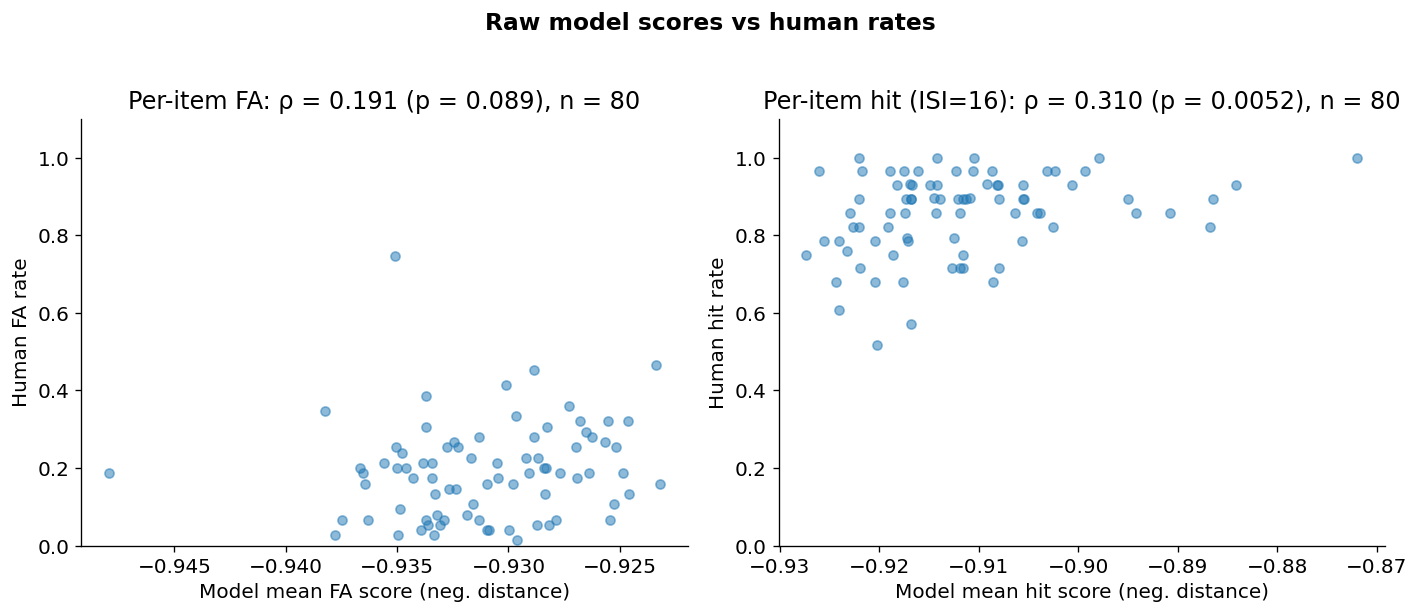

In [51]:
# ── Scatter plots: Model vs Human per sound ──
from scipy.stats import spearmanr

# ====================================================================
# 1. Raw-score scatters (mean model score vs human rate)
# ====================================================================

# --- FA scatter ---
common_fa_items = sorted(set(item_fa_scores.keys()) & set(human_fa_mean.keys()))
print(f'Common FA items: {len(common_fa_items)}')

model_fa_arr = np.array([np.mean(item_fa_scores[k]) for k in common_fa_items])
human_fa_arr = np.array([human_fa_mean[k] for k in common_fa_items])
model_fa_neg = -model_fa_arr  # negate: higher = more "old"-like

mask_fa = np.isfinite(model_fa_neg) & np.isfinite(human_fa_arr)
rho_fa, p_fa = spearmanr(model_fa_neg[mask_fa], human_fa_arr[mask_fa])

# --- Hit scatter at ISI ---
isi = 16
risi = isi + 1
model_items_at_isi = {k for k in item_isi_hits if risi in item_isi_hits[k]}
human_items_at_isi = {k for k in human_hit_mean if isi in human_hit_mean[k]}
common_hit_items = sorted(model_items_at_isi & human_items_at_isi)
print(f'Common hit items at ISI={isi}: {len(common_hit_items)}')

m_hit_scores = np.array([np.mean(item_isi_hits[k][risi]) for k in common_hit_items])
h_hit_rates  = np.array([human_hit_mean[k][isi] for k in common_hit_items])
m_hit_neg = -m_hit_scores

mask_hit = np.isfinite(m_hit_neg) & np.isfinite(h_hit_rates)
rho_hit, p_hit = spearmanr(m_hit_neg[mask_hit], h_hit_rates[mask_hit])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(model_fa_neg[mask_fa], human_fa_arr[mask_fa], alpha=0.5, s=30)
axes[0].set_xlabel('Model mean FA score (neg. distance)')
axes[0].set_ylabel('Human FA rate')
axes[0].set_title(f'Per-item FA: ρ = {rho_fa:.3f} (p = {p_fa:.2g}), n = {mask_fa.sum()}')
axes[0].set_ylim(0, 1.1)

axes[1].scatter(m_hit_neg[mask_hit], h_hit_rates[mask_hit], alpha=0.5, s=30)
axes[1].set_xlabel('Model mean hit score (neg. distance)')
axes[1].set_ylabel('Human hit rate')
axes[1].set_title(f'Per-item hit (ISI={isi}): ρ = {rho_hit:.3f} (p = {p_hit:.2g}), n = {mask_hit.sum()}')
axes[1].set_ylim(0, 1.1)


for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Raw model scores vs human rates', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()


In [52]:
# ====================================================================
# 2. Find threshold that matches human overall performance,
#    then compare itemwise rates with equated performance
# ====================================================================

# --- Compute human overall FA rate and hit rate at target ISI ---
human_overall_fa = np.mean([v for v in human_fa_mean.values()])
human_overall_hr = np.mean([human_hit_mean[k][isi]
                            for k in human_hit_mean if isi in human_hit_mean[k]])
print(f'Human overall FA rate: {human_overall_fa:.3f}')
print(f'Human overall hit rate (ISI={isi}): {human_overall_hr:.3f}')

# --- Pool ALL model FA scores (across items) to find threshold ---
all_model_fa = np.concatenate([item_fa_scores[k] for k in item_fa_scores])
all_model_hit = np.concatenate([item_isi_hits[k][risi]
                                for k in item_isi_hits if risi in item_isi_hits[k]])

# For cosine distance: lower score = more similar = more likely "old"
# Threshold τ: model says "old" if score < τ
# FA rate = P(score < τ | lure)  →  match to human FA rate
# Hit rate = P(score < τ | repeat) → match to human hit rate

# Option A: match FA rate
fa_threshold = np.percentile(all_model_fa, 100 * human_overall_fa)
model_far_at_thresh = np.mean(all_model_fa <= fa_threshold)
model_hr_at_thresh  = np.mean(all_model_hit <= fa_threshold)

# Option B: match hit rate
hr_threshold = np.percentile(all_model_hit, 100 * human_overall_hr)
model_far_at_hr_thresh = np.mean(all_model_fa <= hr_threshold)
model_hr_at_hr_thresh  = np.mean(all_model_hit <= hr_threshold)

print(f'\n--- Threshold matched to human FA rate ({human_overall_fa:.3f}) ---')
print(f'  τ = {fa_threshold:.4f}')
print(f'  Model FA rate:  {model_far_at_thresh:.3f}  (target: {human_overall_fa:.3f})')
print(f'  Model hit rate: {model_hr_at_thresh:.3f}  (human: {human_overall_hr:.3f})')

print(f'\n--- Threshold matched to human hit rate ({human_overall_hr:.3f}) ---')
print(f'  τ = {hr_threshold:.4f}')
print(f'  Model FA rate:  {model_far_at_hr_thresh:.3f}  (human: {human_overall_fa:.3f})')
print(f'  Model hit rate: {model_hr_at_hr_thresh:.3f}  (target: {human_overall_hr:.3f})')


Human overall FA rate: 0.192
Human overall hit rate (ISI=16): 0.855

--- Threshold matched to human FA rate (0.192) ---
  τ = 0.9247
  Model FA rate:  0.192  (target: 0.192)
  Model hit rate: 0.853  (human: 0.855)

--- Threshold matched to human hit rate (0.855) ---
  τ = 0.9248
  Model FA rate:  0.195  (human: 0.192)
  Model hit rate: 0.855  (target: 0.855)


Using threshold τ = 0.9247 (matched to human FA rate = 0.192)


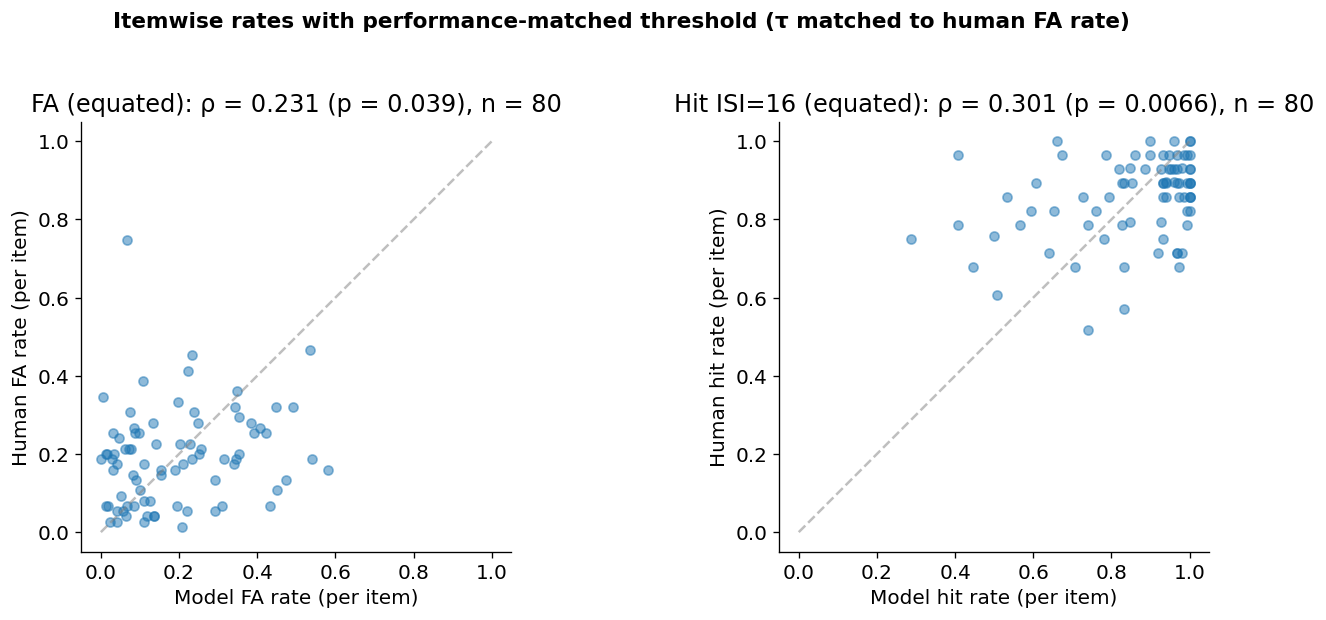


Overall model rates at this threshold:
  FA rate:  0.191 (human: 0.192)
  Hit rate: 0.853 (human: 0.855)


In [55]:
# ====================================================================
# 3. Per-item rates with FA-matched threshold → scatter vs human
# ====================================================================

# Use fa_threshold (matched to human overall FA rate)
threshold = fa_threshold
print(f'Using threshold τ = {threshold:.4f} (matched to human FA rate = {human_overall_fa:.3f})')

# Per-item model FA rate: fraction of FA trials where score < threshold
model_fa_rate_item = {}
for k in item_fa_scores:
    scores = np.array(item_fa_scores[k])
    if len(scores) >= 3:
        model_fa_rate_item[k] = np.mean(scores <= threshold)

# Per-item model hit rate at target ISI
model_hr_item = {}
for k in item_isi_hits:
    if risi in item_isi_hits[k]:
        scores = np.array(item_isi_hits[k][risi])
        if len(scores) >= 3:
            model_hr_item[k] = np.mean(scores <= threshold)

# --- Scatter: FA rate (equated) ---
common_fa_eq = sorted(set(model_fa_rate_item) & set(human_fa_mean))
mfa = np.array([model_fa_rate_item[k] for k in common_fa_eq])
hfa = np.array([human_fa_mean[k] for k in common_fa_eq])
valid = np.isfinite(mfa) & np.isfinite(hfa)
rho_fa_eq, p_fa_eq = spearmanr(mfa[valid], hfa[valid])

# --- Scatter: hit rate (equated) ---
common_hr_eq = sorted(set(model_hr_item) & set(human_items_at_isi))
# need human hit rate for these items at this ISI
common_hr_eq = [k for k in common_hr_eq if k in human_hit_mean and isi in human_hit_mean[k]]
mhr = np.array([model_hr_item[k] for k in common_hr_eq])
hhr = np.array([human_hit_mean[k][isi] for k in common_hr_eq])
valid_hr = np.isfinite(mhr) & np.isfinite(hhr)
rho_hr_eq, p_hr_eq = spearmanr(mhr[valid_hr], hhr[valid_hr])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(mfa[valid], hfa[valid], alpha=0.5, s=30)
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[0].set_xlabel('Model FA rate (per item)')
axes[0].set_ylabel('Human FA rate (per item)')
axes[0].set_title(f'FA (equated): ρ = {rho_fa_eq:.3f} (p = {p_fa_eq:.2g}), n = {valid.sum()}')
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_aspect('equal')

axes[1].scatter(mhr[valid_hr], hhr[valid_hr], alpha=0.5, s=30)
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[1].set_xlabel('Model hit rate (per item)')
axes[1].set_ylabel('Human hit rate (per item)')
axes[1].set_title(f'Hit ISI={isi} (equated): ρ = {rho_hr_eq:.3f} (p = {p_hr_eq:.2g}), n = {valid_hr.sum()}')
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_aspect('equal')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'Itemwise rates with performance-matched threshold (τ matched to human FA rate)',
             fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
plt.show()

print(f'\nOverall model rates at this threshold:')
print(f'  FA rate:  {np.mean(mfa[valid]):.3f} (human: {np.mean(hfa[valid]):.3f})')
print(f'  Hit rate: {np.mean(mhr[valid_hr]):.3f} (human: {np.mean(hhr[valid_hr]):.3f})')


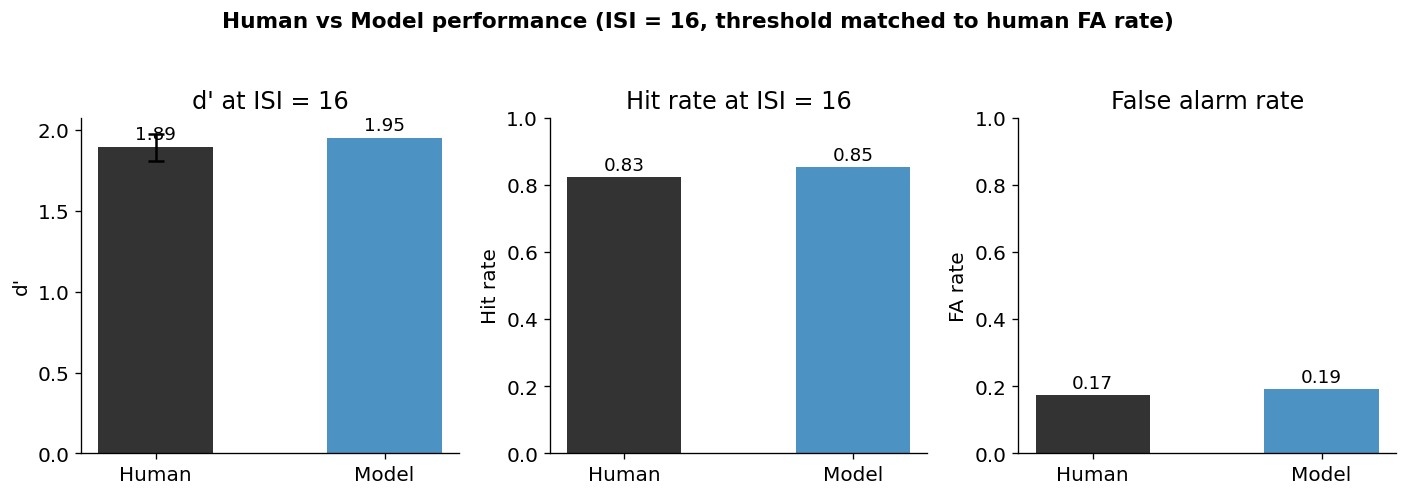

In [54]:
# ── Bar plot: Human vs Model performance at ISI=16 ──
from utls.analysis_helpers import auroc_to_dprime
from utls.roc_utils import roc_from_arrays

isi = 16
risi = isi + 1

# --- Human d' and rates at ISI=16 ---
human_dp_isi16 = human_dp[list(grid_isis).index(isi)]
human_sem_isi16 = human_sem[list(grid_isis).index(isi)]

# --- Model d' at ISI=16 (from the itemwise run) ---
model_dp_isi16 = dp_itemwise[isi]

# --- Model hit rate and FA rate at threshold ---
model_far_isi16 = model_far_at_thresh
model_hr_isi16 = model_hr_at_thresh

# --- Human hit rate and FA rate at ISI=16 ---
# Aggregate across participants
human_hr_vals, human_far_vals = [], []
for run in human_runs:
    entries = run['isi_hit_dists'].get(isi, [])
    fas = run['fas']
    if len(entries) < 2 or len(fas) < 2:
        continue
    hits_resp = np.array([s for s, t in entries])
    fas_resp = np.array(fas, dtype=float)
    # Human responses are 0-3; "yes" = response > 1
    human_hr_vals.append(np.mean(hits_resp > 1))
    human_far_vals.append(np.mean(fas_resp > 1))

human_hr_isi16 = np.mean(human_hr_vals)
human_far_isi16 = np.mean(human_far_vals)

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# d' comparison
ax = axes[0]
bars = ax.bar(['Human', 'Model'], [human_dp_isi16, model_dp_isi16],
              color=['black', 'tab:blue'], alpha=0.8, width=0.5)
ax.errorbar(0, human_dp_isi16, yerr=human_sem_isi16, fmt='none',
            color='black', capsize=5, capthick=1.5)
ax.set_ylabel("d'")
ax.set_title(f"d' at ISI = {isi}")
for bar, val in zip(bars, [human_dp_isi16, model_dp_isi16]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=11)

# Hit rate comparison
ax = axes[1]
bars = ax.bar(['Human', 'Model'], [human_hr_isi16, model_hr_isi16],
              color=['black', 'tab:blue'], alpha=0.8, width=0.5)
ax.set_ylabel('Hit rate')
ax.set_title(f'Hit rate at ISI = {isi}')
ax.set_ylim(0, 1)
for bar, val in zip(bars, [human_hr_isi16, model_hr_isi16]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=11)

# FA rate comparison
ax = axes[2]
bars = ax.bar(['Human', 'Model'], [human_far_isi16, model_far_at_thresh],
              color=['black', 'tab:blue'], alpha=0.8, width=0.5)
ax.set_ylabel('FA rate')
ax.set_title('False alarm rate')
ax.set_ylim(0, 1)
for bar, val in zip(bars, [human_far_isi16, model_far_at_thresh]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=11)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'Human vs Model performance (ISI = {isi}, threshold matched to human FA rate)',
             fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
plt.show()


/tmp/ipykernel_3517620/3971585077.py:56: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_hr, p_hr = spearmanr(mhr[valid_hr], hhr[valid_hr])


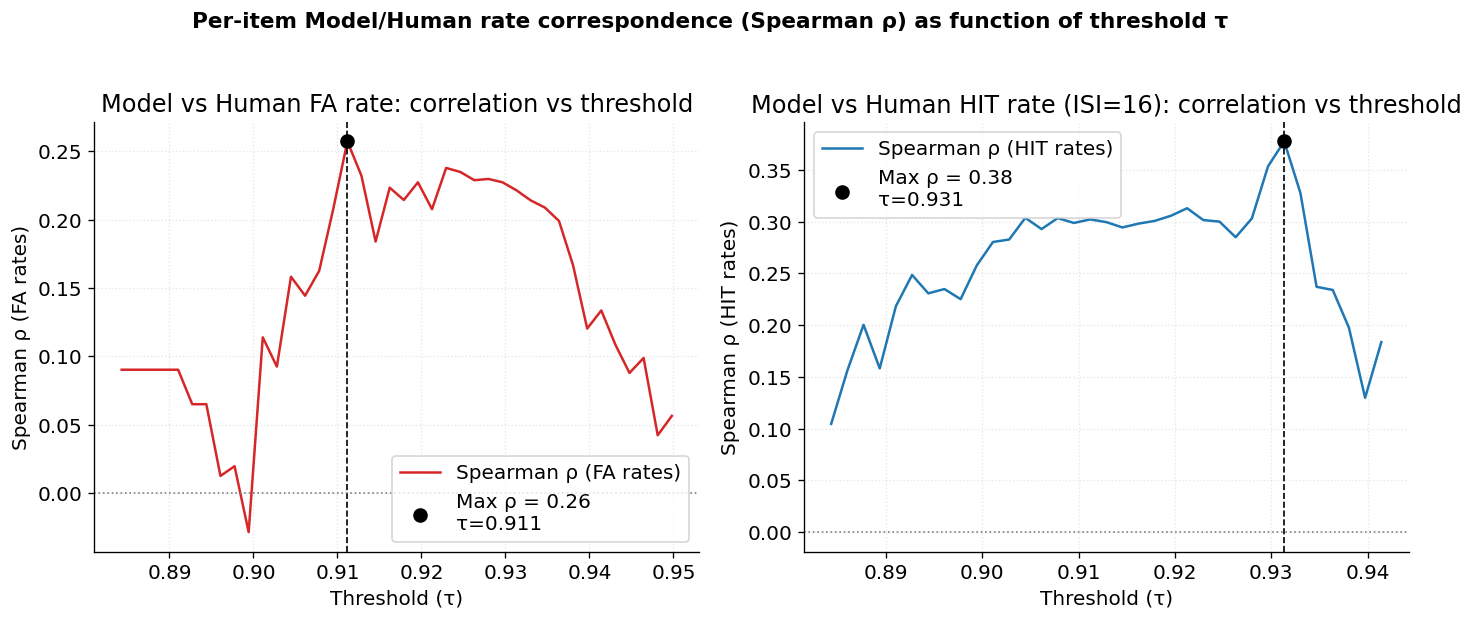

In [ ]:
# ====================================================================
# 5. Per-item rates: Correlation vs threshold
# ====================================================================

# Sweep thresholds across all model FA and HIT scores
# Get a reasonable range of all observed scores as possible thresholds
all_fa_scores = np.concatenate([np.array(v) for v in item_fa_scores.values() if len(v) > 0])
all_hr_scores = np.concatenate([
    np.array(s)
    for k in item_isi_hits for s in ([item_isi_hits[k][risi]] if (risi in item_isi_hits[k]) else [])
    if len(s) > 0
])
all_scores = np.concatenate([all_fa_scores, all_hr_scores])
q1, q99 = np.percentile(all_scores, [1, 99])  # avoid extreme tails

n_thresh = 40
thresholds = np.linspace(q1, q99, n_thresh)

fa_corrs = []
fa_corr_ps = []
hit_corrs = []
hit_corr_ps = []

for threshold in thresholds:
    # --- Model FA rate at this threshold ---
    model_fa_rate_item = {}
    for k in item_fa_scores:
        scores = np.array(item_fa_scores[k])
        if len(scores) >= 3:
            model_fa_rate_item[k] = np.mean(scores <= threshold)
    common_fa_eq = sorted(set(model_fa_rate_item) & set(human_fa_mean))
    mfa = np.array([model_fa_rate_item[k] for k in common_fa_eq])
    hfa = np.array([human_fa_mean[k] for k in common_fa_eq])
    valid = np.isfinite(mfa) & np.isfinite(hfa)
    if valid.sum() >= 3:
        rho_fa, p_fa = spearmanr(mfa[valid], hfa[valid])
    else:
        rho_fa, p_fa = np.nan, np.nan
    fa_corrs.append(rho_fa)
    fa_corr_ps.append(p_fa)

    # --- Model HIT rate at this threshold ---
    model_hr_item = {}
    for k in item_isi_hits:
        if risi in item_isi_hits[k]:
            scores = np.array(item_isi_hits[k][risi])
            if len(scores) >= 3:
                model_hr_item[k] = np.mean(scores <= threshold)
    common_hr_eq = sorted(set(model_hr_item) & set(human_items_at_isi))
    # Restrict to items that have corresponding human hit rates for this ISI
    common_hr_eq = [k for k in common_hr_eq if k in human_hit_mean and isi in human_hit_mean[k]]
    mhr = np.array([model_hr_item[k] for k in common_hr_eq])
    hhr = np.array([human_hit_mean[k][isi] for k in common_hr_eq])
    valid_hr = np.isfinite(mhr) & np.isfinite(hhr)
    if valid_hr.sum() >= 3:
        rho_hr, p_hr = spearmanr(mhr[valid_hr], hhr[valid_hr])
    else:
        rho_hr, p_hr = np.nan, np.nan
    hit_corrs.append(rho_hr)
    hit_corr_ps.append(p_hr)

# Convert lists to arrays for analysis
fa_corrs = np.array(fa_corrs)
hit_corrs = np.array(hit_corrs)
fa_corr_ps = np.array(fa_corr_ps)
hit_corr_ps = np.array(hit_corr_ps)

# Find the threshold with maximal correlation for FA and HIT
best_fa_idx = np.nanargmax(np.abs(fa_corrs))
best_hr_idx = np.nanargmax(np.abs(hit_corrs))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(thresholds, fa_corrs, label="Spearman ρ (FA rates)", color="tab:red")
axes[0].axvline(thresholds[best_fa_idx], color="k", linestyle="--", lw=1)
axes[1].axvline(fa_threshold, color="r", linestyle="--", lw=1)

axes[0].scatter(
    thresholds[best_fa_idx],
    fa_corrs[best_fa_idx],
    color="k", s=60, zorder=10, label=f'Max ρ = {fa_corrs[best_fa_idx]:.2f}\nτ={thresholds[best_fa_idx]:.3f}'
)
axes[0].set_xlabel("Threshold (τ)")
axes[0].set_ylabel("Spearman ρ (FA rates)")
axes[0].set_title("Model vs Human FA rate: correlation vs threshold")
axes[0].legend()
axes[0].axhline(0, color='gray', ls=':', lw=1)
axes[0].grid(ls=':', alpha=0.3)

axes[1].plot(thresholds, hit_corrs, label="Spearman ρ (HIT rates)", color="tab:blue")
axes[1].axvline(thresholds[best_hr_idx], color="k", linestyle="--", lw=1)
axes[1].axvline(fa_threshold, color="r", linestyle="--", lw=1)

axes[1].scatter(
    thresholds[best_hr_idx],
    hit_corrs[best_hr_idx],
    color="k", s=60, zorder=10, label=f'Max ρ = {hit_corrs[best_hr_idx]:.2f}\nτ={thresholds[best_hr_idx]:.3f}'
)
axes[1].set_xlabel("Threshold (τ)")
axes[1].set_ylabel("Spearman ρ (HIT rates)")
axes[1].set_title(f"Model vs Human HIT rate (ISI={isi}): correlation vs threshold")
axes[1].legend()
axes[1].axhline(0, color='gray', ls=':', lw=1)
axes[1].grid(ls=':', alpha=0.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("Per-item Model/Human rate correspondence (Spearman ρ) as function of threshold τ", fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
plt.show()
